<a href="https://colab.research.google.com/github/hdflorez/Entrega_3/blob/main/VideoGameSales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis de Datos | 190304018-1 | 2026-1** | **Entrega 3** |

**Integrantes - Equipo 8:**
*   Mariana Villegas Ochoa
*   Melisa Colorado Soto
*   Jaider Santiago Villa David
*   Hernán Darío Flórez Martínez
---

# **Dataset: Video Game Sales**
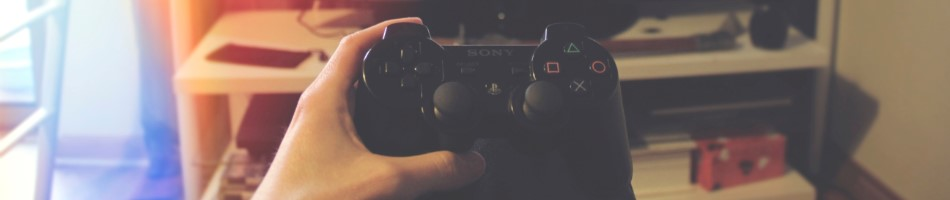

Recuperado de: https://www.kaggle.com/datasets/gregorut/videogamesales

In [40]:
#Importe desde Kaggle
import kagglehub

#Descargar la versión más actualizada
path = kagglehub.dataset_download("gregorut/videogamesales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'videogamesales' dataset.
Path to dataset files: /kaggle/input/videogamesales


In [41]:
#Importación de librerías y carga de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')
sns.set_palette("husl")

# Ubicación del dataset
path_dataset = path + "/vgsales.csv"

# Cargar el dataset
df = pd.read_csv(path_dataset)

# Visualización rápida
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
print(df.head())

Dimensiones del dataset: (16598, 11)

Primeras filas:
   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  


# **Fase 1: Comprensión del problema**

## **Descripción del contexto del dataset**
El dataset Video Game Sales contiene información sobre 16,598 registros de videojuegos comercializados entre 1980 y 2020, recopilados desde la plataforma VGChartz (vgchartz.com). Cada registro representa un título único con datos sobre su plataforma, año de lanzamiento, género, publisher y ventas desglosadas por región geográfica.


| Variable | Tipo | Descripción |
|---|---|---|
| Rank | Numérico | Posición según ventas globales |
| Name | Texto | Nombre del videojuego |
| Platform | Categórica | Consola/plataforma (31 únicas) |
| Year | Numérico | Año de lanzamiento (1980 - 2020) |
| Genre | Categórica | Género del juego (12 únicos) |
| Publisher | Categórica | Empresa publicadora |
| NA_Sales | Numérico | Ventas en Norteamérica (millones de copias) |
| EU_Sales | Numérico | Ventas en Europa (millones de copias) |
| JP_Sales | Numérico | Ventas en Japón (millones de copias) |
| Other_Sales | Numérico | Ventas en otras regiones (millones de copias) |
| Global_Sales | Numérico | Ventas totales globales (millones de copias) |

Como datos relevantes del dataset, encontramos:
*   Ventas globales totales:8,920.44 millones de copias
*   Publisher con más títulos: Electronic Arts (1,351 juegos)
*   Plataforma con más títulos: DS (2,163 juegos)
*   Género más frecuente: Action (3,313 juegos)

## **Identificación del problema de análisis o negocio**
La industria de los videojuegos se caracteriza por su alta competitividad y constante evolución. En este contexto, Publishers, desarrolladores e inversionistas necesitan entender con precisión los factores que influyen en el éxito comercial de un título, como el género, la plataforma, la región de comercialización y el año de lanzamiento. El propósito de este análisis es convertir datos históricos de ventas en información estratégica que permita respaldar la toma de decisiones informadas en áreas estratégicas como el desarrollo, el marketing y la distribución.

## **Preguntas clave de análisis**

* ¿Qué géneros de videojuegos generan mayores ventas globales y cómo varía esta tendencia entre regiones (NA, EU, JP)?
* ¿Cómo ha evolucionado el volumen de ventas globales a lo largo de los años y qué plataformas dominaron cada era?
* ¿Qué tan concentrado está el mercado en términos de publishers? ¿Un pequeño grupo de empresas acapara la mayor parte de las ventas globales?

# **Fase 2: Formulación de hipótesis**

## **Hipótesis 1. Género y ventas globales**
Los videojuegos de género Action y Sports, al ser los dos géneros más producidos, generan ventas globales mayores que los demás géneros.

* **H₀:** Los géneros Action/Sports tienen la misma mediana de ventas globales que los demás géneros
* **H₁:** Los géneros Action/Sports tienen una mediana de ventas globales significativamente mayor

* **Justificación:** Action y Sports son los dos géneros más producidos del dataset con 3,316 y 2,346 títulos respectivamente, sumando 5,555 juegos en total. Además, lideran en ventas globales acumuladas con 1,722M y 1,309M de copias. Determinando si esta predominación es estadísticamente significativa permite a publishers y desarrolladores validar si apostar por estos géneros representa una ventaja comercial real.
* **Variables relacionadas:** Genre, Global_Sales
* **Prueba estadística:** Mann-Whitney U (no paramétrica, dado que la distribución de ventas es fuertemente asimétrica)
* **Conclusión preliminar:** Se rechaza H₀. La diferencia en ventas entre Action/Sports y el resto de géneros es estadísticamente significativa.











In [42]:
#Procesamiento
df = df.dropna(subset=['Year', 'Publisher'])

action_sports = df[df['Genre'].isin(['Action', 'Sports'])]['Global_Sales']
otros = df[~df['Genre'].isin(['Action', 'Sports'])]['Global_Sales']

u_stat, p_h1 = stats.mannwhitneyu(action_sports, otros, alternative='greater')
print("TABLA DE RESULTADOS\n")
print(f"H1 | Títulos Action/Sports:  {len(action_sports)}")
print(f"H1 | Títulos Otros:          {len(otros)}")
print(f"H1 | Mediana Action/Sports:  {action_sports.median():.2f}M")
print(f"H1 | Mediana Otros:          {otros.median():.2f}M")
print(f"H1 | U-statistic:            {u_stat:,.0f}")
print(f"H1 | valor p:                {p_h1:.6f} ---> {'Rechazar H₀' if p_h1 < 0.05 else 'No rechazar H₀'}")

TABLA DE RESULTADOS

H1 | Títulos Action/Sports:  5555
H1 | Títulos Otros:          10736
H1 | Mediana Action/Sports:  0.21M
H1 | Mediana Otros:          0.15M
H1 | U-statistic:            32,752,337
H1 | valor p:                0.000000 ---> Rechazar H₀


## **Hipótesis 2. Dominio regional de Norteamérica (NA) en ventas**
Norteamérica (NA) es la región con mayores ventas de videojuegos, siendo estadísticamente mayor a Europa (EU) y Japón (JP).

* **H₀:** No existe diferencia significativa entre las ventas de NA y las de EU/JP
* **H₁:** Las ventas en NA son significativamente mayores que en EU y JP

* **Justificación:** Entender qué región concentra el mayor volumen de ventas es fundamental para definir estrategias de lanzamiento y marketing basadas en la localización. Si NA domina de forma estadísticamente significativa, los publishers deberían priorizar ese mercado en sus campañas.
* **Variables relacionadas:** NA_Sales, EU_Sales, JP_Sales, Global_Sales
* **Prueba estadística:** Prueba de Wilcoxon para comparar muestras relacionadas por cada juego: cada título cuenta con datos de ventas en las tres regiones.
* **Conclusión preliminar:** Se rechaza H₀ en ambos casos. NA concentra casi la mitad de las ventas globales y su superioridad sobre EU y JP es estadísticamente significativa.

In [43]:
#Importe de liberías
import pandas as pd

df_clean = df.dropna(subset=['Year', 'Publisher'])

#Consolidado por región
print("TABLA DE RESULTADOS\n")
regiones = ['NA_Sales', 'EU_Sales', 'JP_Sales']
for r in regiones:
    pct = df[r].sum() / df['Global_Sales'].sum() * 100
    print(f"{r:<12} | Total: {df[r].sum():>8.2f}M | % Global: {pct:.1f}%")

#Procesamiento
t_eu, p_eu = stats.wilcoxon(df['NA_Sales'], df['EU_Sales'])
t_jp, p_jp = stats.wilcoxon(df['NA_Sales'], df['JP_Sales'])
print(f"\nH2 | Wilcoxon NA vs EU ---> p-value: {p_eu:.6f} | {'Rechazar H₀' if p_eu < 0.05 else 'No rechazar H₀'}")
print(f"H2 | Wilcoxon NA vs JP ---> p-value: {p_jp:.6f} | {'Rechazar H₀' if p_jp < 0.05 else 'No rechazar H₀'}")

TABLA DE RESULTADOS

NA_Sales     | Total:  4327.65M | % Global: 49.1%
EU_Sales     | Total:  2406.69M | % Global: 27.3%
JP_Sales     | Total:  1284.27M | % Global: 14.6%

H2 | Wilcoxon NA vs EU ---> p-value: 0.000000 | Rechazar H₀
H2 | Wilcoxon NA vs JP ---> p-value: 0.000000 | Rechazar H₀


# **Fase 3: Preparacion de datos**

## **1. Exploracion**

In [44]:
# Información general
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  float64
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


In [45]:
# Estadísticas descriptivas
df.describe(include='all')

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.000000,16291,16291,16291.000000,16291,16291,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
unique,NaN,11325,31,NaN,12,576,NaN,NaN,NaN,NaN,NaN
top,NaN,Need for Speed: Most Wanted,DS,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,2131,NaN,3251,1339,NaN,NaN,NaN,NaN,NaN
mean,8290.190228,NaN,NaN,2006.405561,NaN,NaN,0.265647,0.147731,0.078833,0.048426,0.540910
std,4792.654450,NaN,NaN,5.832412,NaN,NaN,0.822432,0.509303,0.311879,0.190083,1.567345
min,1.000000,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4132.500000,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8292.000000,NaN,NaN,2007.000000,NaN,NaN,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12439.500000,NaN,NaN,2010.000000,NaN,NaN,0.240000,0.110000,0.040000,0.040000,0.480000


## **2. Limpieza de datos**

In [46]:
# Registros duplicados
df.duplicated().sum()

np.int64(0)

In [47]:
#Normalizar nombres de columnas
df.columns = df.columns.str.lower().str.strip()

df.columns

Index(['rank', 'name', 'platform', 'year', 'genre', 'publisher', 'na_sales',
       'eu_sales', 'jp_sales', 'other_sales', 'global_sales'],
      dtype='object')

## **3. Tratamiento de valores nulos**

In [48]:
#Identificar nulos
df.isnull().sum()

,0
rank,0
name,0
platform,0
year,0
genre,0
publisher,0
na_sales,0
eu_sales,0
jp_sales,0
other_sales,0


In [49]:
# Trtamiento
# Año
df['year'] = df['year'].fillna(df['year'].median())

df['year'] = df['year'].astype(int)

In [50]:
# publisher
df['publisher'] = df['publisher'].fillna('Unknown')

In [51]:
# Verirficar
df.isnull().sum()

,0
rank,0
name,0
platform,0
year,0
genre,0
publisher,0
na_sales,0
eu_sales,0
jp_sales,0
other_sales,0


## **4. Tansformaciones**

In [52]:
#Crear metricas derivadas
# Total ventas (validacion)
df['total_sales_calc'] = (

    df['na_sales'] +

    df['eu_sales'] +

    df['jp_sales'] +

    df['other_sales']

)

In [53]:
# Region dominante
df['top_region'] = df[['na_sales','eu_sales','jp_sales','other_sales']].idxmax(axis=1)

In [54]:
# Decada del juego
df['decade'] = (df['year']//10)*10

In [55]:
# Conversion de tipos
categorical_cols = ['platform','genre','publisher']

for col in categorical_cols:
    df[col] = df[col].astype('category')

## **5. Selección de variables**

In [56]:
df = df.drop(columns=['rank'])

In [57]:
# Dataset final
df.head()

,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,total_sales_calc,top_region,decade
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,na_sales,2000
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,na_sales,1980
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,na_sales,2000
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,na_sales,2000
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,na_sales,1990


## **6. Definir dimensiones y metricas**

In [58]:
# DIMENSIONES (atributos descriptivos)
dimensiones = [
    'name',
    'platform',
    'genre',
    'publisher',
    'year',
    'decade',
    'top_region'
]

In [59]:
# MÉTRICAS (variables numéricas)
metricas = [
    'na_sales',
    'eu_sales',
    'jp_sales',
    'other_sales',
    'global_sales',
    'total_sales_calc'
]

## **7. Dataset listo ara analisis**

In [60]:
df.to_csv("vgsales_clean.csv", index=False)

## **8. Vaidacion final**

In [61]:
print("Shape final:", df.shape)
df.info()
df.describe()

Shape final: (16291, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   name              16291 non-null  object  
 1   platform          16291 non-null  category
 2   year              16291 non-null  int64   
 3   genre             16291 non-null  category
 4   publisher         16291 non-null  category
 5   na_sales          16291 non-null  float64 
 6   eu_sales          16291 non-null  float64 
 7   jp_sales          16291 non-null  float64 
 8   other_sales       16291 non-null  float64 
 9   global_sales      16291 non-null  float64 
 10  total_sales_calc  16291 non-null  float64 
 11  top_region        16291 non-null  object  
 12  decade            16291 non-null  int64   
dtypes: category(3), float64(6), int64(2), object(2)
memory usage: 1.5+ MB


,year,na_sales,eu_sales,jp_sales,other_sales,global_sales,total_sales_calc,decade
count,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
mean,2006.405561,0.265647,0.147731,0.078833,0.048426,0.540910,0.540637,2001.814499
std,5.832412,0.822432,0.509303,0.311879,0.190083,1.567345,1.567460,6.643438
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,0.000000,1980.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,0.060000,2000.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,0.170000,2000.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000,0.480000,2010.000000
max,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000,82.740000,2020.000000
